In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from astro_plot_utils import (
    load_table,
    extract_columns,
    hist_density,
    plot_step_hist
)

In [2]:
PATH_Q1  = "/data/astro/scratch/vdeshpan/data/Q1_general.parquet"
PATH_FS2 = "/data/astro/scratch/vdeshpan/data/FS2_general.parquet"

ZP_Q1 = 23.9
ZP_FS2 = -48.6

FLUX_COLS_Q1 = [
    "flux_vis_1fwhm_aper",
    "flux_vis_2fwhm_aper",
    "flux_vis_3fwhm_aper",
    "flux_vis_4fwhm_aper"
]

In [3]:
table_q1 = load_table(PATH_Q1, format="parquet")

fluxes_q1 = extract_columns(table_q1, FLUX_COLS_Q1)

mags_q1 = {}
for col in FLUX_COLS_Q1:
    flux = fluxes_q1[col]
    mags_q1[col] = -2.5 * np.log10(flux.clip(1e-30)) + ZP_Q1   # avoid log(0)
    mags_q1[col][flux <= 0] = np.nan

print("Q1 magnitudes computed for apertures 1–4")

Q1 magnitudes computed for apertures 1–4


In [4]:
table_fs2 = load_table(PATH_FS2, format="parquet")

# Extract needed columns
cols_fs2 = [
    "ra_gal", "dec_gal",
    "euclid_vis_el_model3_ext_odonnell_ext",
    "euclid_vis_el_model3_ext_odonnell_ext_error_realization",
]

data_fs2 = extract_columns(table_fs2, cols_fs2, dropna=False)

ra  = data_fs2["ra_gal"]
dec = data_fs2["dec_gal"]

mask_region1 = (ra >= 145) & (ra <= 232.5) & (dec >= 83.42) & (dec <= 89.27)

flux_ext   = data_fs2["euclid_vis_el_model3_ext_odonnell_ext"          ][mask_region1]
flux_err_r = data_fs2["euclid_vis_el_model3_ext_odonnell_ext_error_realization"][mask_region1]

flux_eff_fs2 = flux_ext + flux_err_r
mag_fs2_reg1 = -2.5 * np.log10(flux_eff_fs2) + ZP_FS2
mag_fs2_reg1[flux_eff_fs2 <= 0] = np.nan

print(f"FS2 region 1: {len(mag_fs2_reg1):,} galaxies after mask")

FS2 region 1: 114,713 galaxies after mask


/tmp/ipykernel_184/3860356767.py:21: RuntimeWarning: invalid value encountered in log10
  mag_fs2_reg1 = -2.5 * np.log10(flux_eff_fs2) + ZP_FS2


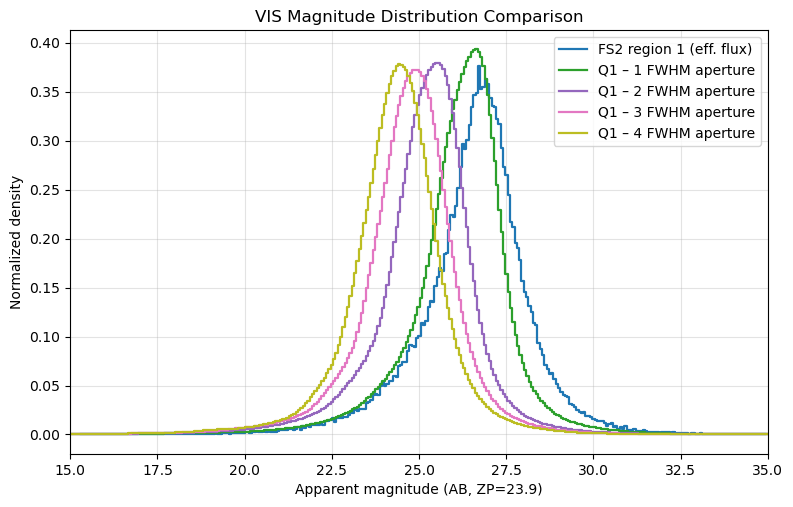

In [6]:
hist_data = []
labels = []

# Mock region 1
h, c = hist_density(mag_fs2_reg1, bins=300, clip=(15, 35))
hist_data.append((h, c))
labels.append("FS2 region 1 (eff. flux)")

# Q1 four apertures
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for i, col in enumerate(FLUX_COLS_Q1, 1):
    h, c = hist_density(mags_q1[col], bins=300, clip=(15, 35))
    hist_data.append((h, c))
    labels.append(f"Q1 – {i} FWHM aperture")

plot_step_hist(
    hist_data,
    labels=labels,
    title="VIS Magnitude Distribution Comparison",
    xlabel="Apparent magnitude (AB, ZP=23.9)",
    xlim=(15, 35)
)